In [25]:
from keras.layers import Dense, MaxPooling2D
from keras.models import Sequential
from keras.datasets import mnist

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [26]:
# Data load
(train_imgs, train_labels),(test_imgs, test_labels)=mnist.load_data()

In [27]:
# Data Checkout
print ("The number of training examples is: ", train_imgs.shape[0])
print ("The number of test examples is: ", test_imgs.shape[0])
print ("The size of every img is: ", train_imgs.shape[1:])
num_classes=len(np.unique(train_labels))
print ("The number of classes is: ", num_classes)

The number of training examples is:  60000
The number of test examples is:  10000
The size of every img is:  (28, 28)
The number of classes is:  10


Text(0.5, 1.0, 'Ground truth is: 4')

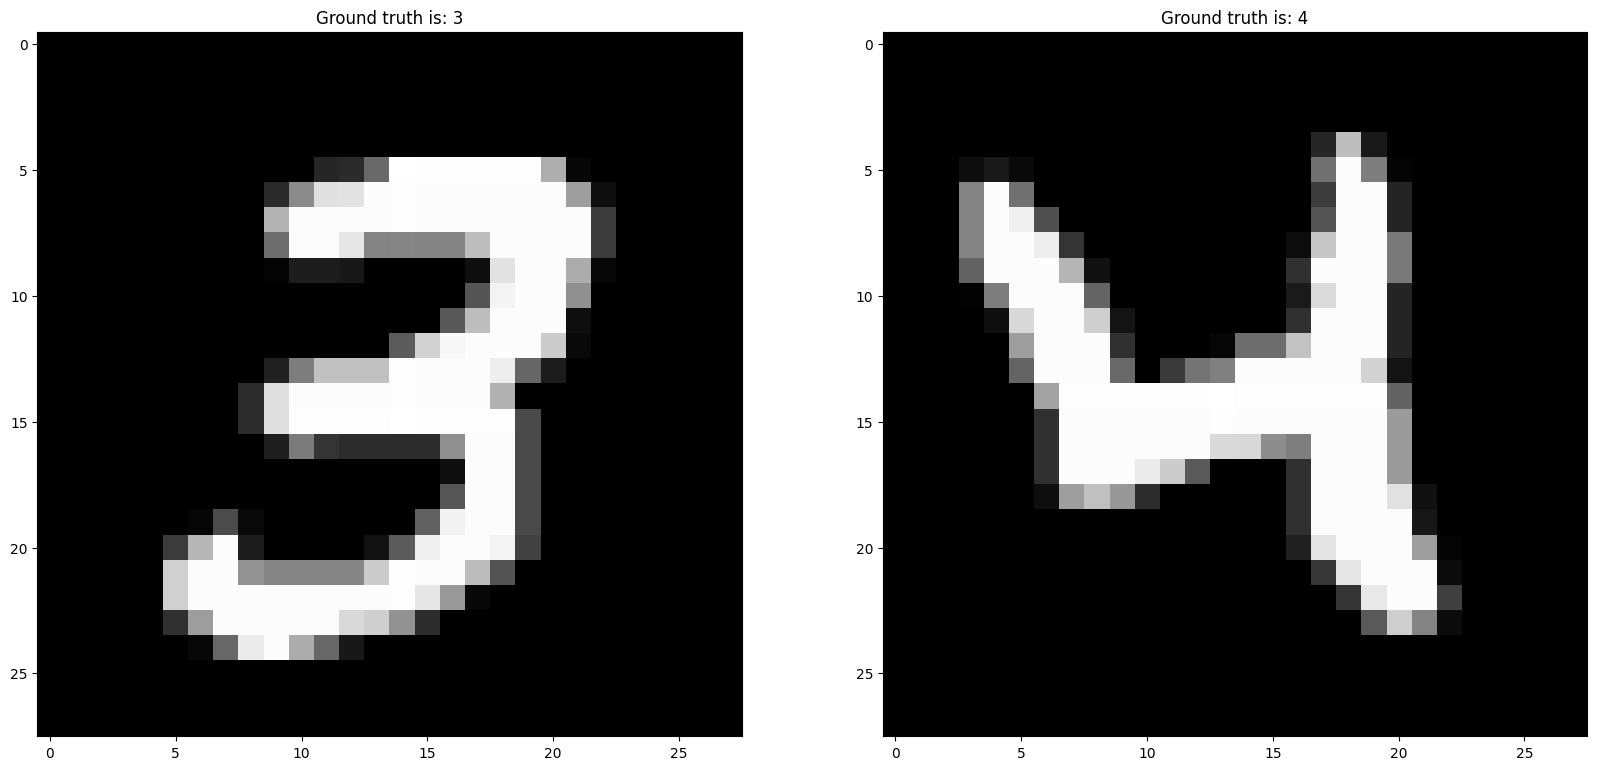

In [28]:
# printing out some samples
figure,(ax1,ax2)=plt.subplots(1,2,figsize=(20,10))

ax1.imshow(train_imgs[7,:,:],cmap='gray')
ax1.set_title("Ground truth is: {}".format(train_labels[7]))

ax2.imshow(train_imgs[20,:,:],cmap='gray')
ax2.set_title("Ground truth is: {}".format(train_labels[20]))

In [29]:
# Reshaping the input to be a vector instead of an array
dim_array=np.prod(train_imgs.shape[1:])
train_data=train_imgs.reshape(train_imgs.shape[0],dim_array)
test_data=test_imgs.reshape(test_imgs.shape[0],dim_array)

In [30]:
# Convert images to png (scale from 0 to 1)
train_data=train_data.astype('float32')
test_data=test_data.astype('float32')

train_data/=255
test_data/=255

In [31]:
#Converting labels to one-hot encoding form
from tensorflow.keras.utils import to_categorical

train_labels_one_hot=to_categorical(train_labels)
test_labels_one_hot=to_categorical(test_labels)

In [32]:
print("Before encoding",train_labels[5])
print("After encoding",train_labels_one_hot[5])

Before encoding 2
After encoding [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


In [33]:
#Create a network

model=Sequential()
model.add(Dense(512,activation='sigmoid',input_shape=(dim_array,)))
model.add(Dense(512,activation='sigmoid'))
model.add(Dense(num_classes,activation='softmax'))

/Users/cristallagus/miniconda3/envs/tf-metal-311/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Configure a network
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# train a model
history = model.fit(train_data, train_labels_one_hot, batch_size=256, epochs=20, verbose=1,
                   validation_data=(test_data, test_labels_one_hot))

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.5927 - loss: 1.3039 - val_accuracy: 0.8753 - val_loss: 0.4014
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8991 - loss: 0.3371 - val_accuracy: 0.9162 - val_loss: 0.2788
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9160 - loss: 0.2782 - val_accuracy: 0.9252 - val_loss: 0.2448
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9314 - loss: 0.2301 - val_accuracy: 0.9357 - val_loss: 0.2097
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9430 - loss: 0.1885 - val_accuracy: 0.9379 - val_loss: 0.2002
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9493 - loss: 0.1688 - val_accuracy: 0.9429 - val_loss: 0.1827
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9566 - loss: 0.1460 - val_accuracy: 0.9511 - val_loss: 0.1613
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.9612 - loss: 0.1300 - val_a

In [ ]:
# test
[test_loss, test_acc] = model.evaluate(test_data, test_labels_one_hot)
print("Evaluation result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9677 - loss: 0.1035
Evaluation result on Test Data : Loss = 0.08697773516178131, accuracy = 0.9728999733924866


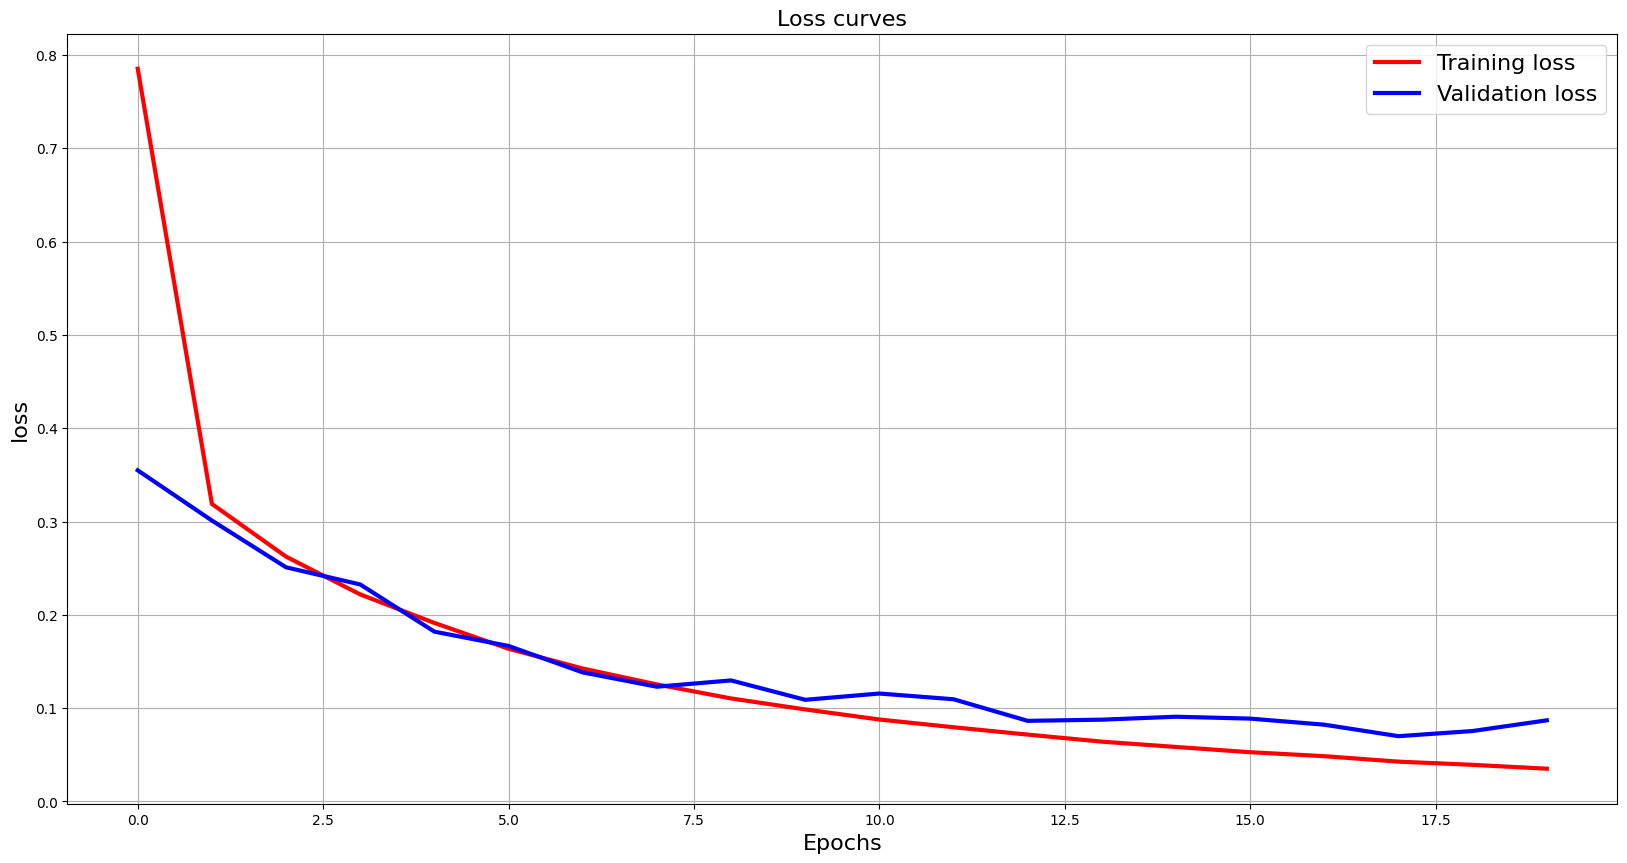

In [ ]:
plt.figure(figsize=[20,10])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss','Validation loss'],fontsize=16)
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('loss',fontsize=16)
plt.title('Loss curves',fontsize=16)
plt.grid()

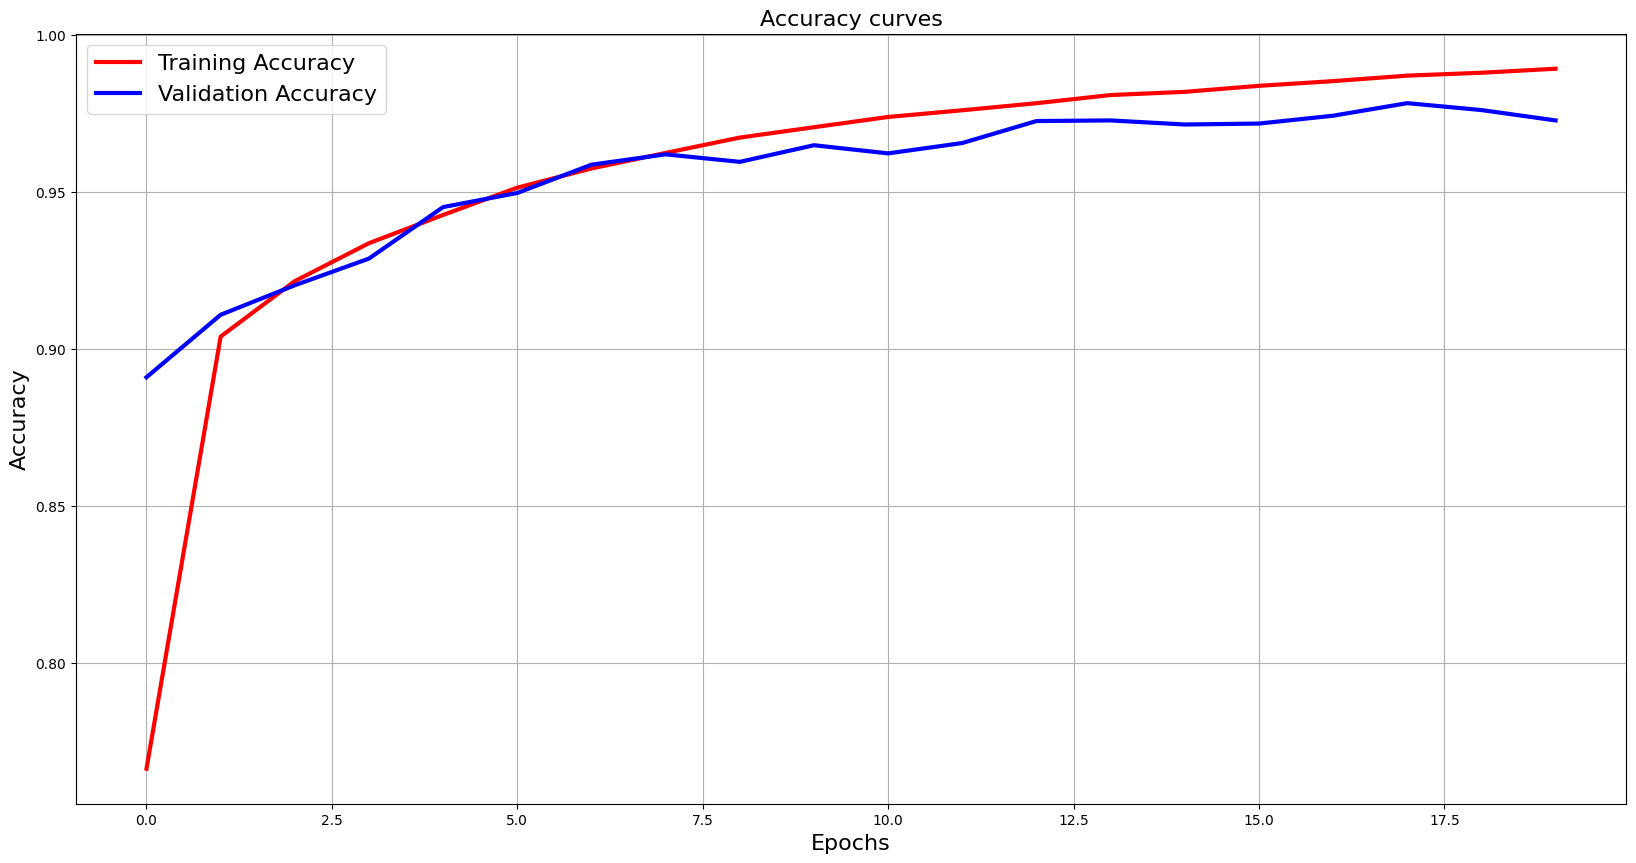

In [ ]:
plt.figure(figsize=[20,10])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy','Validation Accuracy'],fontsize=16)
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy curves',fontsize=16)
plt.grid()


In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
# Check how dropout will affect validation accuracy

from keras.layers import Dropout, Input

model=Sequential()
model.add(Dense(512,activation='sigmoid',input_shape=[dim_array,]))
model.add(Dropout(0.5))
model.add(Dense(512,activation='sigmoid'))
model.add(Dropout(0.5))
model.add(Dense(num_classes,activation='softmax'))

In [ ]:
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
history = model.fit(train_data, train_labels_one_hot, batch_size=256, epochs=20, verbose=1,
                   validation_data=(test_data, test_labels_one_hot))

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.4922 - loss: 1.5040 - val_accuracy: 0.8946 - val_loss: 0.3693
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8641 - loss: 0.4400 - val_accuracy: 0.9148 - val_loss: 0.2890
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8928 - loss: 0.3531 - val_accuracy: 0.9278 - val_loss: 0.2435
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9086 - loss: 0.3018 - val_accuracy: 0.9356 - val_loss: 0.2118
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9172 - loss: 0.2657 - val_accuracy: 0.9436 - val_loss: 0.1857
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9284 - loss: 0.2342 - val_accuracy: 0.9476 - val_loss: 0.1704
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9350 - loss: 0.2159 - val_accuracy: 0.9522 - val_loss: 0.1530
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9389 - loss: 0.2007 - val_acc

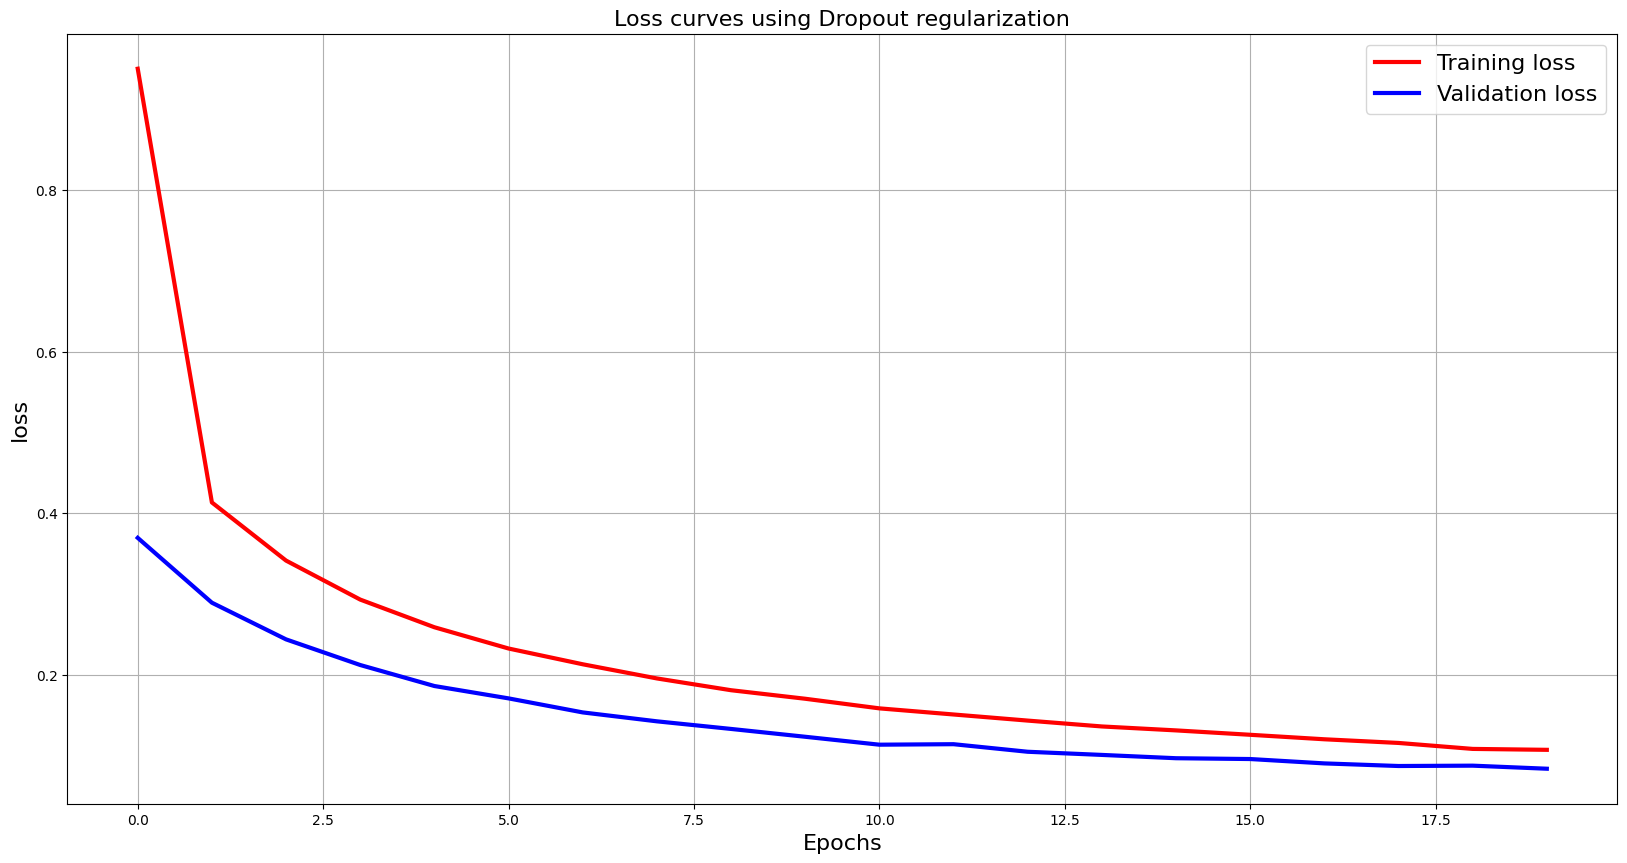

In [ ]:
plt.figure(figsize=[20,10])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss','Validation loss'],fontsize=16)
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('loss',fontsize=16)
plt.title('Loss curves using Dropout regularization',fontsize=16)
plt.grid()

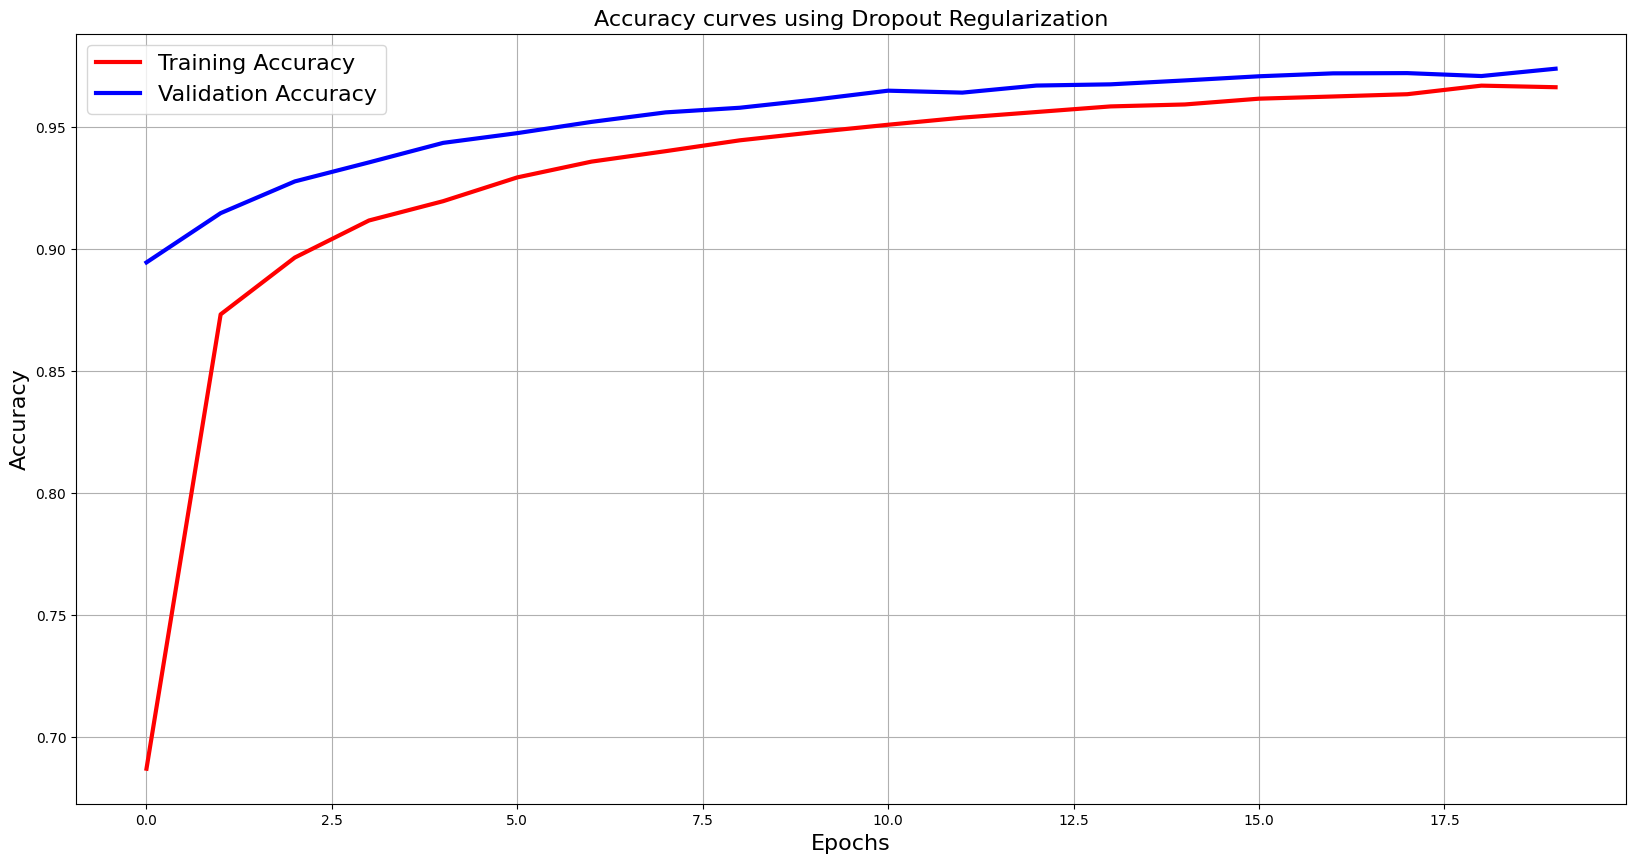

In [ ]:
plt.figure(figsize=[20,10])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy','Validation Accuracy'],fontsize=16)
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy curves using Dropout Regularization',fontsize=16)
plt.grid()

In [ ]:
model.predict(test_data[[8],:])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


array([[9.2960465e-05, 6.9143944e-06, 6.1523446e-05, 1.6347324e-06,
        7.7840785e-04, 3.3780247e-01, 6.5988475e-01, 2.3785518e-09,
        9.0124732e-04, 4.7001537e-04]], dtype=float32)

Text(0.5, 1.0, 'Ground truth is: 9')

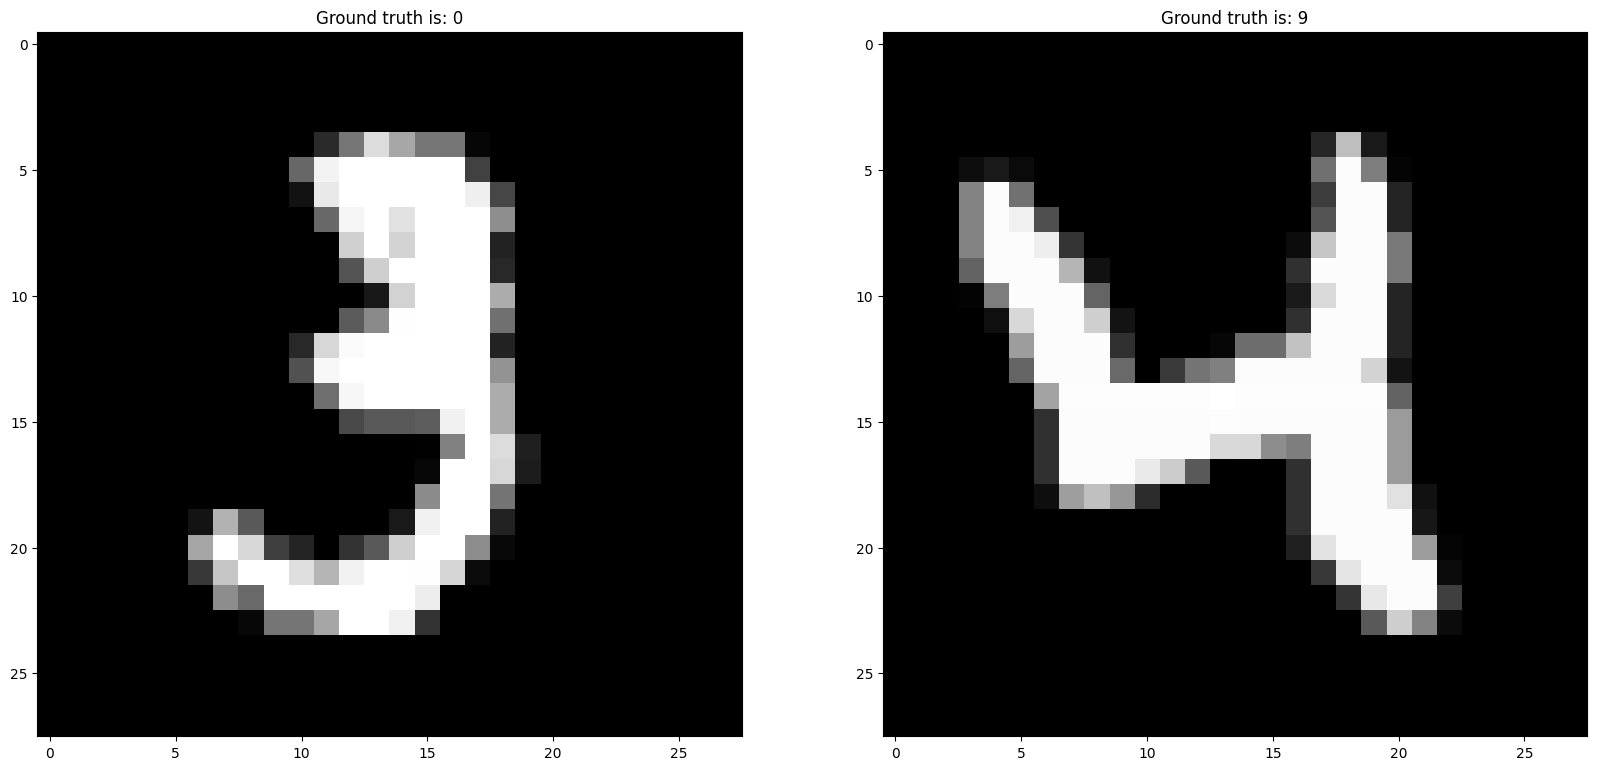

In [ ]:
# printing out some samples
figure,(ax1,ax2)=plt.subplots(1,2,figsize=(20,10))

ax1.imshow(train_imgs[10,:,:],cmap='gray')
ax1.set_title("Ground truth is: {}".format(test_labels[10]))

ax2.imshow(train_imgs[20,:,:],cmap='gray')
ax2.set_title("Ground truth is: {}".format(test_labels[20]))